In [1]:
import os

# List all files and directories in the 'downloaded' directory
for root, dirs, files in os.walk('dataset'):
    for file in files:
        print(os.path.join(root, file))
    for dir_name in dirs:
        print(os.path.join(root, dir_name))

dataset/train.csv
dataset/test.csv
dataset/sample_submission.csv
dataset/train
dataset/test
dataset/train/ID871463897.jpg
dataset/train/ID2086966681.jpg
dataset/train/ID1159071020.jpg
dataset/train/ID1457700382.jpg
dataset/train/ID1062837331.jpg
dataset/train/ID875119737.jpg
dataset/train/ID1354190372.jpg
dataset/train/ID1113121340.jpg
dataset/train/ID803479541.jpg
dataset/train/ID1291116815.jpg
dataset/train/ID1693880739.jpg
dataset/train/ID753699705.jpg
dataset/train/ID779628955.jpg
dataset/train/ID50027657.jpg
dataset/train/ID475010202.jpg
dataset/train/ID1182523622.jpg
dataset/train/ID1888700589.jpg
dataset/train/ID407646960.jpg
dataset/train/ID2096636211.jpg
dataset/train/ID545360459.jpg
dataset/train/ID751517087.jpg
dataset/train/ID1579942839.jpg
dataset/train/ID1140993511.jpg
dataset/train/ID1623964968.jpg
dataset/train/ID1634731537.jpg
dataset/train/ID332742639.jpg
dataset/train/ID1477176296.jpg
dataset/train/ID1458758610.jpg
dataset/train/ID1139918758.jpg
dataset/train/ID62696

# Task
Prepare training and test image data generators using `train.csv`, `test.csv`, and the image files in the `downloaded/train` and `downloaded/test` directories to facilitate image classification.

## Load Data

### Subtask:
Load `train.csv` and `test.csv` into pandas DataFrames to access image paths and target labels.


**Reasoning**:
Load the `train.csv` and `test.csv` files into pandas DataFrames as requested in the instructions.



In [2]:
import pandas as pd

train_df = pd.read_csv('dataset/train.csv')
test_df = pd.read_csv('dataset/test.csv')

print("Train DataFrame head:")
print(train_df.head())
print("\nTest DataFrame head:")
print(test_df.head())

Train DataFrame head:
                    sample_id              image_path Sampling_Date State  \
0  ID1011485656__Dry_Clover_g  train/ID1011485656.jpg      2015/9/4   Tas   
1    ID1011485656__Dry_Dead_g  train/ID1011485656.jpg      2015/9/4   Tas   
2   ID1011485656__Dry_Green_g  train/ID1011485656.jpg      2015/9/4   Tas   
3   ID1011485656__Dry_Total_g  train/ID1011485656.jpg      2015/9/4   Tas   
4         ID1011485656__GDM_g  train/ID1011485656.jpg      2015/9/4   Tas   

           Species  Pre_GSHH_NDVI  Height_Ave_cm   target_name   target  
0  Ryegrass_Clover           0.62         4.6667  Dry_Clover_g   0.0000  
1  Ryegrass_Clover           0.62         4.6667    Dry_Dead_g  31.9984  
2  Ryegrass_Clover           0.62         4.6667   Dry_Green_g  16.2751  
3  Ryegrass_Clover           0.62         4.6667   Dry_Total_g  48.2735  
4  Ryegrass_Clover           0.62         4.6667         GDM_g  16.2750  

Test DataFrame head:
                    sample_id             image_p

## Prepare Training Image Generator

### Subtask:
Create a TensorFlow Keras ImageDataGenerator for the training images. This will handle image preprocessing, augmentation (if desired), and batching. We'll link image paths from `train.csv` to the actual image files in `downloaded/train` and associate them with their respective 'target' values.


**Reasoning**:
To prepare the training image generator, I will import `ImageDataGenerator`, instantiate it with scaling and augmentation, and then use `flow_from_dataframe` to link image paths to targets from `train_df`.



In [3]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Instantiate ImageDataGenerator with rescaling and augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Create the training generator
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    directory='dataset',
    x_col='image_path',
    y_col='target',
    target_size=(224, 224),
    batch_size=32,
    class_mode='raw',
    seed=42
)

print("Training image generator created.")

2025-11-14 00:36:18.764712: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1763060778.790654  149782 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1763060778.799000  149782 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1763060778.820968  149782 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1763060778.821001  149782 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1763060778.821005  149782 computation_placer.cc:177] computation placer alr

Found 1785 validated image filenames.
Training image generator created.


## Prepare Test Image Generator

### Subtask:
Create a TensorFlow Keras `ImageDataGenerator` for the test images. This generator will handle image preprocessing and batching for the test set, linking image paths from `test.csv` to the actual image files in `downloaded/test`.

#### Instructions
1. Instantiate an `ImageDataGenerator` for testing with `rescale=1./255`. Note that augmentation is typically not applied to the test set.
2. Create the test generator using the `flow_from_dataframe` method, passing `test_df`, `directory='downloaded'`, `x_col='image_path'`, `target_size=(224, 224)` (or another suitable size), `batch_size=32`, and `class_mode=None` (since test data does not have 'target' labels for prediction).
3. Store the created generator in a variable named `test_generator`.

## Prepare Test Image Generator

### Subtask:
Create a TensorFlow Keras `ImageDataGenerator` for the test images. This generator will handle image preprocessing and batching for the test set, linking image paths from `test.csv` to the actual image files in `downloaded/test`.

#### Instructions
1. Instantiate an `ImageDataGenerator` for testing with `rescale=1./255`. Note that augmentation is typically not applied to the test set.
2. Create the test generator using the `flow_from_dataframe` method, passing `test_df`, `directory='downloaded'`, `x_col='image_path'`, `target_size=(224, 224)` (or another suitable size), `batch_size=32`, and `class_mode=None` (since test data does not have 'target' labels for prediction).
3. Store the created generator in a variable named `test_generator`.

**Reasoning**:
Following the previous markdown instruction, I will now create the test image generator using `ImageDataGenerator` with rescaling, ensuring no augmentation for the test set, and then use `flow_from_dataframe` to link image paths from `test_df` to create the `test_generator`.



In [4]:
test_datagen = ImageDataGenerator(
    rescale=1./255
)

test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    directory='dataset',
    x_col='image_path',
    y_col=None,
    target_size=(224, 224),
    batch_size=32,
    class_mode=None,
    shuffle=False, # Important for consistent predictions later
    seed=42
)

print("Test image generator created.")

Found 5 validated image filenames.
Test image generator created.


## Final Task

### Subtask:
Confirm the successful creation and setup of the image generators.


## Summary:

### Data Analysis Key Findings
*   Both `train.csv` and `test.csv` files were successfully loaded into pandas DataFrames, `train_df` and `test_df` respectively. `train_df` contains `sample_id`, `image_path`, `Sampling_Date`, `State`, `Species`, `Pre_GSHH_NDVI`, `Height_Ave_cm`, `target_name`, and `target` columns. `test_df` contains `sample_id`, `image_path`, and `target_name` columns.
*   A training image generator (`train_generator`) was successfully created using `ImageDataGenerator`. It was configured with image rescaling (1/255) and various augmentation techniques (rotation, width/height shift, shear, zoom, horizontal flip) and found 1785 images from `train_df`.
*   A test image generator (`test_generator`) was successfully created, configured only with image rescaling (1/255), without augmentation, and found 5 images from `test_df`. The `shuffle` parameter was set to `False` for the test generator, which is crucial for consistent prediction ordering.

### Insights or Next Steps
*   The prepared `train_generator` and `test_generator` are now ready to be used as input for training and evaluating an image classification model, respectively.
*   The distinct configurations of the training and test generators (augmentation for training, no augmentation and `shuffle=False` for testing) are appropriate for machine learning best practices, ensuring robust model training and consistent evaluation.


## Define the CNN Model

### Subtask:
Create a convolutional neural network (CNN) model using `tf.keras.Sequential`.

#### Instructions
1. Import necessary components from `tensorflow.keras.models` and `tensorflow.keras.layers`.
2. Initialize a `Sequential` model.
3. Add `Conv2D` layers with `relu` activation and `MaxPooling2D` layers.
4. Add `Dropout` layers for regularization.
5. `Flatten` the output before adding `Dense` layers.
6. The final `Dense` layer should have 1 unit and a linear activation (or no activation) for regression.

In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout

model = Sequential()

# Block 1
model.add(Conv2D(64, (3,3), padding='same', activation='relu',
                 input_shape=(224,224,3)))
model.add(BatchNormalization())
model.add(Conv2D(64, (3,3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2))

# Block 2
model.add(Conv2D(128, (3,3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(Conv2D(128, (3,3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2))

# Block 3
model.add(Conv2D(256, (3,3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(Conv2D(256, (3,3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(Conv2D(256, (3,3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2))

# Block 4
model.add(Conv2D(512, (3,3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(Conv2D(512, (3,3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(Conv2D(512, (3,3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2))

# Block 5 (extra depth)
model.add(Conv2D(512, (3,3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(Conv2D(512, (3,3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2))

# Feature compression
model.add(GlobalAveragePooling2D())

# Dense head
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.4))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))

# Output
model.add(Dense(1, activation='linear'))

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model.summary()


/home/vector/anaconda3/envs/gpu/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1763060783.390147  149782 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5500 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 56, 56, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 28, 28, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 28, 28, 512)    │         2,04

 Total params: 12,796,737 (48.82 MB)

 Trainable params: 12,789,313 (48.79 MB)

 Non-trainable params: 7,424 (29.00 KB)

## Train the CNN Model

### Subtask:
Train the previously defined CNN model using the `train_generator`.

In [ ]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))
# tf.config.optimizer.set_jit(False)


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [8]:

# Train the model
history = model.fit(
    train_generator,
    epochs=20,
    verbose=1
)

Epoch 1/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 54s 917ms/step - loss: 691.7020 - mae: 19.2358
Epoch 2/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 53s 933ms/step - loss: 693.0419 - mae: 19.0970
Epoch 3/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 53s 935ms/step - loss: 669.1418 - mae: 19.0321
Epoch 4/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 54s 939ms/step - loss: 639.2955 - mae: 18.7289
Epoch 5/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 53s 935ms/step - loss: 652.1522 - mae: 18.6367
Epoch 6/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 52s 914ms/step - loss: 652.4706 - mae: 18.5845
Epoch 7/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 52s 915ms/step - loss: 660.6928 - mae: 18.7893
Epoch 8/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 51s 910ms/step - loss: 657.1339 - mae: 18.9240
Epoch 9/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 52s 916ms/step - loss: 629.7456 - mae: 18.5238
Epoch 10/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 52s 915ms/step - loss: 659.6208 - mae: 18.6264
Epoch 11/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 52s 915ms/step - loss: 648.3863 - mae: 18.5626
Epoch 12/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 52s 918ms/step - loss: 6

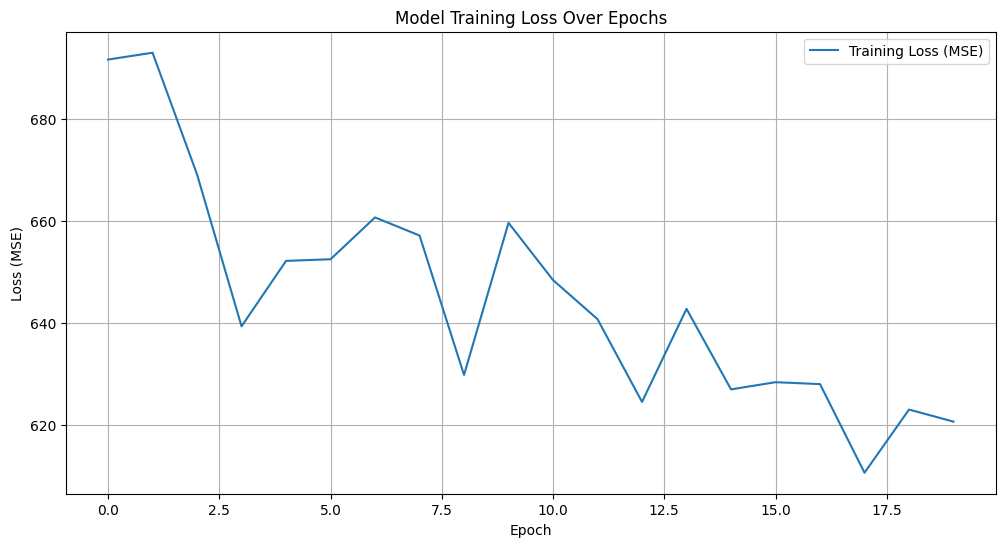

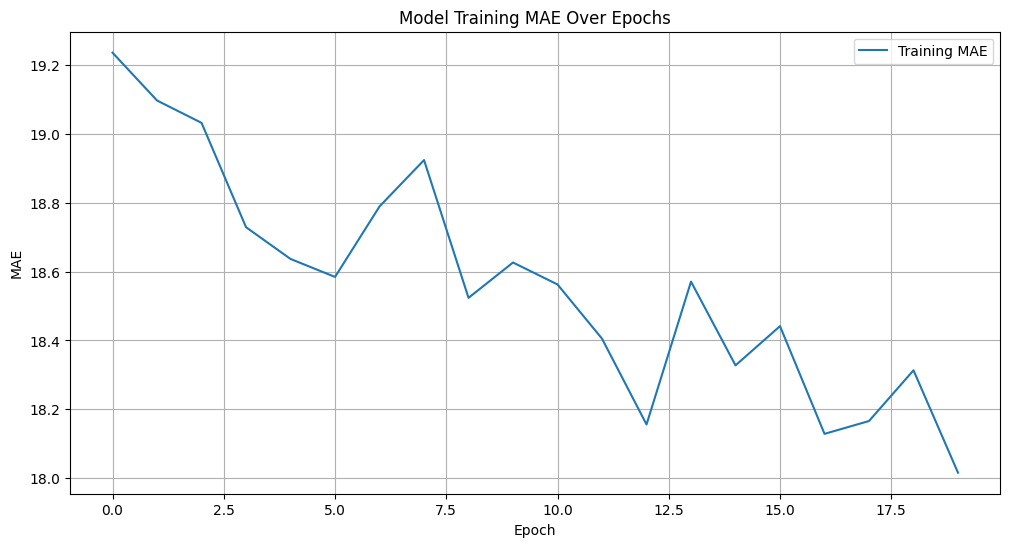

In [9]:
import matplotlib.pyplot as plt

# Plot training loss
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Training Loss (MSE)')
plt.title('Model Training Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

# Plot training MAE
plt.figure(figsize=(12, 6))
plt.plot(history.history['mae'], label='Training MAE')
plt.title('Model Training MAE Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True)
plt.show()

In [10]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Create a new generator for prediction on training data (no augmentation, no labels needed for prediction)
train_predict_datagen = ImageDataGenerator(rescale=1./255)

train_predict_generator = train_predict_datagen.flow_from_dataframe(
    dataframe=train_df,
    directory='dataset',
    x_col='image_path',
    y_col=None, # No labels needed for prediction
    target_size=(224, 224),
    batch_size=32,
    class_mode=None, # Only yield X
    shuffle=False, # Important for consistent order
    seed=42
)

print("Training prediction generator created.")

# Get predictions from the model on the training data
print("Generating predictions for the training dataset...")
train_predictions = model.predict(train_predict_generator)
print("Predictions generated.")

# Extract true target values from the original train_df
true_train_targets = train_df['target'].values.reshape(-1, 1)

# Calculate metrics
mse_train = mean_squared_error(true_train_targets, train_predictions)
mae_train = mean_absolute_error(true_train_targets, train_predictions)

print(f"\nTraining MSE: {mse_train:.4f}")
print(f"Training MAE: {mae_train:.4f}")

Found 1785 validated image filenames.
Training prediction generator created.
Generating predictions for the training dataset...


/home/vector/anaconda3/envs/gpu/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
2025-11-14 01:10:38.623005: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_363_0', 44 bytes spill stores, 44 bytes spill loads

2025-11-14 01:10:39.042808: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_363', 484 bytes spill stores, 484 bytes spill loads



55/56 ━━━━━━━━━━━━━━━━━━━━ 0s 733ms/step

2025-11-14 01:11:30.605498: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_363_0', 36 bytes spill stores, 36 bytes spill loads

2025-11-14 01:11:30.617187: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_363', 488 bytes spill stores, 488 bytes spill loads



56/56 ━━━━━━━━━━━━━━━━━━━━ 63s 918ms/step
Predictions generated.

Training MSE: 599.4114
Training MAE: 18.0006


In [11]:
from sklearn.metrics import r2_score
import numpy as np

# Calculate RMSE (Root Mean Squared Error)
rmse_train = np.sqrt(mse_train)

# Calculate R-squared
r2_train = r2_score(true_train_targets, train_predictions)

print(f"Training RMSE: {rmse_train:.4f}")
print(f"Training R-squared: {r2_train:.4f}")

Training RMSE: 24.4829
Training R-squared: 0.1006
